# Object-count metrics across the boombox-object-count sweep

Bars for all 9 runs from `scripts/boombox_object_count.sh`
(`bb-count-gastro-*`, `bb-count-plastic-*`, `bb-combined-*`), grouped by
**object** = (cube count, box the score is measured against). `gastro 1-cube`
and `plastic 1-cube` are different objects, so a combined run's gastro-side
score (`eval/*`) and plastic-side score (`box2-eval/*`) never share a bar --
that gives 4 objects total: `1-cube`/`2-cubes` × `gastro`/`plastic`
(`OBJECT_ORDER` in the config cell).

Metric is picked with the `METRIC` env var (`iou` by default) -- any key in
`viz.data.METRIC_KEYS` works (`bce`, `iou`, the `localization_*` keys,
`contour`, `mass`).

Per-sample scores come straight from each run's saved prediction tensors
(`outputs_history/eval/<split>` and, for the combined runs,
`outputs_history/box2-eval/<split>`), scored the same way `viz/data.py` does
(`utils.metrics`) -- these numbers match the run's own `logs-rank0.txt` and the
viz dashboard. `viz.data.load_run` itself only ever scans `outputs/eval`, so
`box2-eval` (the plastic side of a combined run) is loaded with a small local
helper below instead. Every bucket used here was already logged during
training -- no forward pass was needed to fill in a missing score.

`*-speaker` eval buckets are excluded by default (`INCLUDE_SPEAKER = False`):
per the eval-split-leak fix, those splits are leaked by design (no held-out
speaker), so their near-1.0 IoU is not comparable to the other buckets.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (str(ROOT), str(ROOT / "src")):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from viz.data import load_gt
from utils.metrics import soft_iou, mass_error, contour_f, localization, LOC_KEYS

%matplotlib inline

## Config

In [2]:
# ---- edit me ------------------------------------------------------------
METRIC = os.environ.get("METRIC", "iou")  # any of: bce, iou, localization_*, contour, mass
INCLUDE_SPEAKER = False  # *-speaker eval buckets are leaked (see eval-split-leak fix); off by default

RUNS_DIR = ROOT / "runs"
GASTRO_EXPERIMENT = ROOT / "experiments" / "31_07_2026_gastronorm_exp1"
PLASTIC_EXPERIMENT = ROOT / "experiments" / "31_08_2026_green_plastic_two_laser_faces"

# (run name, family). family is what the run was TRAINED on -- gastro-only,
# plastic-only, or both (bb-combined-*).
# A combined run scores against BOTH ground truths: its "eval/*" bucket
# (gastronorm) and its "box2-eval/*" bucket (plastic) -- these are kept as
# SEPARATE objects below (a combined run's gastro-side score never mixes with
# its plastic-side score in the same bar).
RUN_SPECS = [
    ("bb-count-gastro-1cube-v1",       "gastro"),
    ("bb-count-gastro-2cube-v1",       "gastro"),
    ("bb-count-gastro-everything-v1",  "gastro"),
    ("bb-count-plastic-1cube-v1",      "plastic"),
    ("bb-count-plastic-2cube-v1",      "plastic"),
    ("bb-count-plastic-everything-v1", "plastic"),
    ("bb-combined-1cube-v1",           "combined"),
    ("bb-combined-2cube-v1",           "combined"),
    ("bb-combined-everything-v1",      "combined"),
]
assert len(RUN_SPECS) == 9

# Which of a run's 3 variants it is (1cube-trained / 2cube-trained / everything-trained)
# -- picks the color SHADE within a family, so all 9 runs get a distinct color.
def variant_of(name: str) -> str:
    if "1cube" in name:
        return "1cube"
    if "2cube" in name:
        return "2cube"
    return "everything"

# Label printed UNDER each bar for what it was trained on -- box + variant, e.g.
# "gastro 1-cube", "gastro 1-2 cube", "gastro+plastic 2-cube".
BOX_WORD = {"gastro": "gastro", "plastic": "plastic", "combined": "gastro+plastic"}
VARIANT_WORD = {"1cube": "1-cube", "2cube": "2-cube", "everything": "1-2 cube"}

def box_obj_label(family: str, variant: str) -> str:
    return f"{BOX_WORD[family]} {VARIANT_WORD[variant]}"

# Object = (cube count, box the score is measured against). Treating "gastro
# 1-cube" and "plastic 1-cube" as different objects means a combined run's
# eval/* (gastro) and box2-eval/* (plastic) rows land in different bars/groups
# instead of both being called "1-cube".
CUBE_ORDER = ["1-cube", "2-cubes"]
SCORE_BOX_ORDER = ["gastro", "plastic"]
OBJECT_ORDER = [f"{cube} · {box}" for cube in CUBE_ORDER for box in SCORE_BOX_ORDER]

# Train/eval sample counts per run, from the scripts/boombox_object_count.sh header
# table (its COMMON args + --data-dir/--split fully determine these, so they're
# fixed metadata, not something to recompute from noisy outputs_history dumps).
# Combined runs' train count already includes both boxes (gastro + box2-plastic
# concatenated by combine_train_loaders); their eval count is per-bucket instead,
# read off `n` in the results table (matches gastro's own eval count for the "eval"
# bucket, plastic's for "box2-eval").
TRAIN_N = {
    "bb-count-gastro-1cube-v1":       504,
    "bb-count-gastro-2cube-v1":       2040,
    "bb-count-gastro-everything-v1":  2553,
    "bb-count-plastic-1cube-v1":      39,
    "bb-count-plastic-2cube-v1":      508,
    "bb-count-plastic-everything-v1": 527,
    "bb-combined-1cube-v1":           543,
    "bb-combined-2cube-v1":           2548,
    "bb-combined-everything-v1":      3080,
}
# ---------------------------------------------------------------------------

## Load

`load_split_metrics` mirrors `viz.data.load_run`'s scoring (same
`utils.metrics` functions, same "latest saved epoch, keep-last-write-per-sample"
rules) but takes the bucket directory name (`eval` or `box2-eval`) as a
parameter, since `load_run` only ever looks at `outputs/eval`.

In [3]:
def load_split_metrics(name: str, gt, bucket: str = "eval", metric: str = METRIC) -> dict[str, np.ndarray]:
    """{split_name: per-sample metric array} for one run's outputs_history/<bucket>/*."""
    root = RUNS_DIR / name / "outputs_history" / bucket
    out: dict[str, np.ndarray] = {}
    if not root.is_dir():
        return out
    for split_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        files = sorted(split_dir.glob("ep*.pt"))
        if not files:
            continue
        ep_of = lambda f: int(f.name.split("-")[0][2:])
        last = max(ep_of(f) for f in files)
        ids, masks = [], []
        for p in [f for f in files if ep_of(f) == last]:
            obj = torch.load(p, map_location="cpu", weights_only=False)
            ids.append(np.asarray(obj["info"]["sample_id"]).astype(np.int64))
            masks.append(obj["mask_pred"].float().numpy())
        sample_ids = np.concatenate(ids)
        preds = np.concatenate(masks).astype(np.float32)

        # A sample can be written twice in one epoch; keep the later write, like load_run.
        if len(np.unique(sample_ids)) != len(sample_ids):
            keep = np.zeros(len(sample_ids), dtype=bool)
            _, first = np.unique(sample_ids[::-1], return_index=True)
            keep[len(sample_ids) - 1 - first] = True
            sample_ids, preds = sample_ids[keep], preds[keep]

        gt_rows = np.array([gt.row_of.get(int(s), -1) for s in sample_ids])
        keep = gt_rows >= 0
        sample_ids, preds, gt_rows = sample_ids[keep], preds[keep], gt_rows[keep]
        if len(sample_ids) == 0:
            continue

        shape = (preds.shape[-2], preds.shape[-1])
        gt_masks = gt.masks_at(shape)
        if gt_masks is None:
            continue

        pred = torch.from_numpy(preds)
        truth = torch.from_numpy(gt_masks[gt_rows])
        if metric == "bce":
            vals = F.binary_cross_entropy(pred.clamp(1e-6, 1 - 1e-6), truth, reduction="none").mean(dim=(-2, -1)).numpy()
        elif metric == "iou":
            vals = soft_iou(pred, truth).numpy()
        elif metric == "contour":
            vals = contour_f(pred, truth).numpy()
        elif metric == "mass":
            vals = mass_error(pred, truth).numpy()
        elif metric in LOC_KEYS:
            loc, _ = localization(pred, truth, geometry=False)
            vals = loc[metric].numpy()
        else:
            raise ValueError(f"unknown METRIC {metric!r}")
        out[split_dir.name] = vals
    return out


gt_gastro = load_gt(GASTRO_EXPERIMENT)
gt_plastic = load_gt(PLASTIC_EXPERIMENT)
print(f"gastro gt: {len(gt_gastro)} samples | plastic gt: {len(gt_plastic)} samples")

gastro gt: 3007 samples | plastic gt: 601 samples


In [4]:
def canonical_cube(split_name: str) -> str | None:
    """Strip the eval-bucket split name down to a cube-count, or None to drop it."""
    if "speaker" in split_name and not INCLUDE_SPEAKER:
        return None
    for c in CUBE_ORDER:
        if split_name == c or split_name.startswith(c + "-"):
            return c
    return None  # e.g. a leaked *-speaker split when INCLUDE_SPEAKER is False


# Every bucket we load already exists on disk (written during training when
# --data-dir-2/--split-2 turns on the box2-eval loader), so no forward pass is
# needed here -- add an entry to `buckets` below if a future run needs one that
# isn't logged yet.
#
# rows: run, family, variant, bucket, score_box, cube, object, mean, std, n
rows = []
for name, family in RUN_SPECS:
    if family == "gastro":
        buckets = [("eval", gt_gastro, "gastro")]
    elif family == "plastic":
        buckets = [("eval", gt_plastic, "plastic")]
    else:  # combined -- eval/* scores the gastro side, box2-eval/* the plastic side
        buckets = [("eval", gt_gastro, "gastro"), ("box2-eval", gt_plastic, "plastic")]
    for bucket, gt, score_box in buckets:
        splits = load_split_metrics(name, gt, bucket)
        for split_name, vals in splits.items():
            cube = canonical_cube(split_name)
            if cube is None or len(vals) == 0:
                continue
            rows.append(dict(
                run=name, family=family, variant=variant_of(name), bucket=bucket,
                score_box=score_box, cube=cube, object=f"{cube} · {score_box}",
                mean=float(vals.mean()), std=float(vals.std()), n=len(vals),
            ))

import pandas as pd
df = pd.DataFrame(rows)
df["object"] = pd.Categorical(df["object"], [o for o in OBJECT_ORDER if o in df["object"].unique()], ordered=True)
df = df.sort_values(["object", "family", "variant"]).reset_index(drop=True)
print(f"{len(df)} (run, bucket, object) bars, metric={METRIC!r}")
df

16 (run, bucket, object) bars, metric='iou'


,run,family,variant,bucket,score_box,cube,object,mean,std,n
0,bb-combined-1cube-v1,combined,1cube,eval,gastro,1-cube,1-cube · gastro,0.637553,0.244867,127
1,bb-combined-everything-v1,combined,everything,eval,gastro,1-cube,1-cube · gastro,0.060249,0.063926,80
2,bb-count-gastro-1cube-v1,gastro,1cube,eval,gastro,1-cube,1-cube · gastro,0.622452,0.258087,127
3,bb-count-gastro-everything-v1,gastro,everything,eval,gastro,1-cube,1-cube · gastro,0.088671,0.125472,112
4,bb-combined-1cube-v1,combined,1cube,box2-eval,plastic,1-cube,1-cube · plastic,0.049766,0.025523,4
5,bb-combined-everything-v1,combined,everything,box2-eval,plastic,1-cube,1-cube · plastic,0.502150,0.069960,4
6,bb-count-plastic-1cube-v1,plastic,1cube,eval,plastic,1-cube,1-cube · plastic,0.009349,0.000000,4
7,bb-count-plastic-everything-v1,plastic,everything,eval,plastic,1-cube,1-cube · plastic,0.318075,0.186987,4
8,bb-combined-2cube-v1,combined,2cube,eval,gastro,2-cubes,2-cubes · gastro,0.187461,0.115343,72
9,bb-combined-everything-v1,combined,everything,eval,gastro,2-cubes,2-cubes · gastro,0.197280,0.099075,72


## Bar chart

2×2 grid, one panel per object -- rows = box, columns = cube count (so
row-major reading order is `1-cube gastro`, `2-cube gastro`, `1-cube plastic`,
`2-cube plastic`). All 4 panels share the same y-axis scale.

- **color**: one per run -- hue = family (gastro / plastic / combined), shade =
  which variant the run was trained on (1cube-only / 2cube-only / everything).
- **error bar**: +/- 1 std of the per-sample metric within that (run, eval
  bucket).
- **label above bar**: mean value.
- **labels below bar**: box + training variant (`gastro 1-cube`, `gastro
  2-cube`, `gastro 1-2 cube`, `gastro+plastic 2-cube`, ...), then
  `n_train=...` and `n_eval=...` on their own lines.

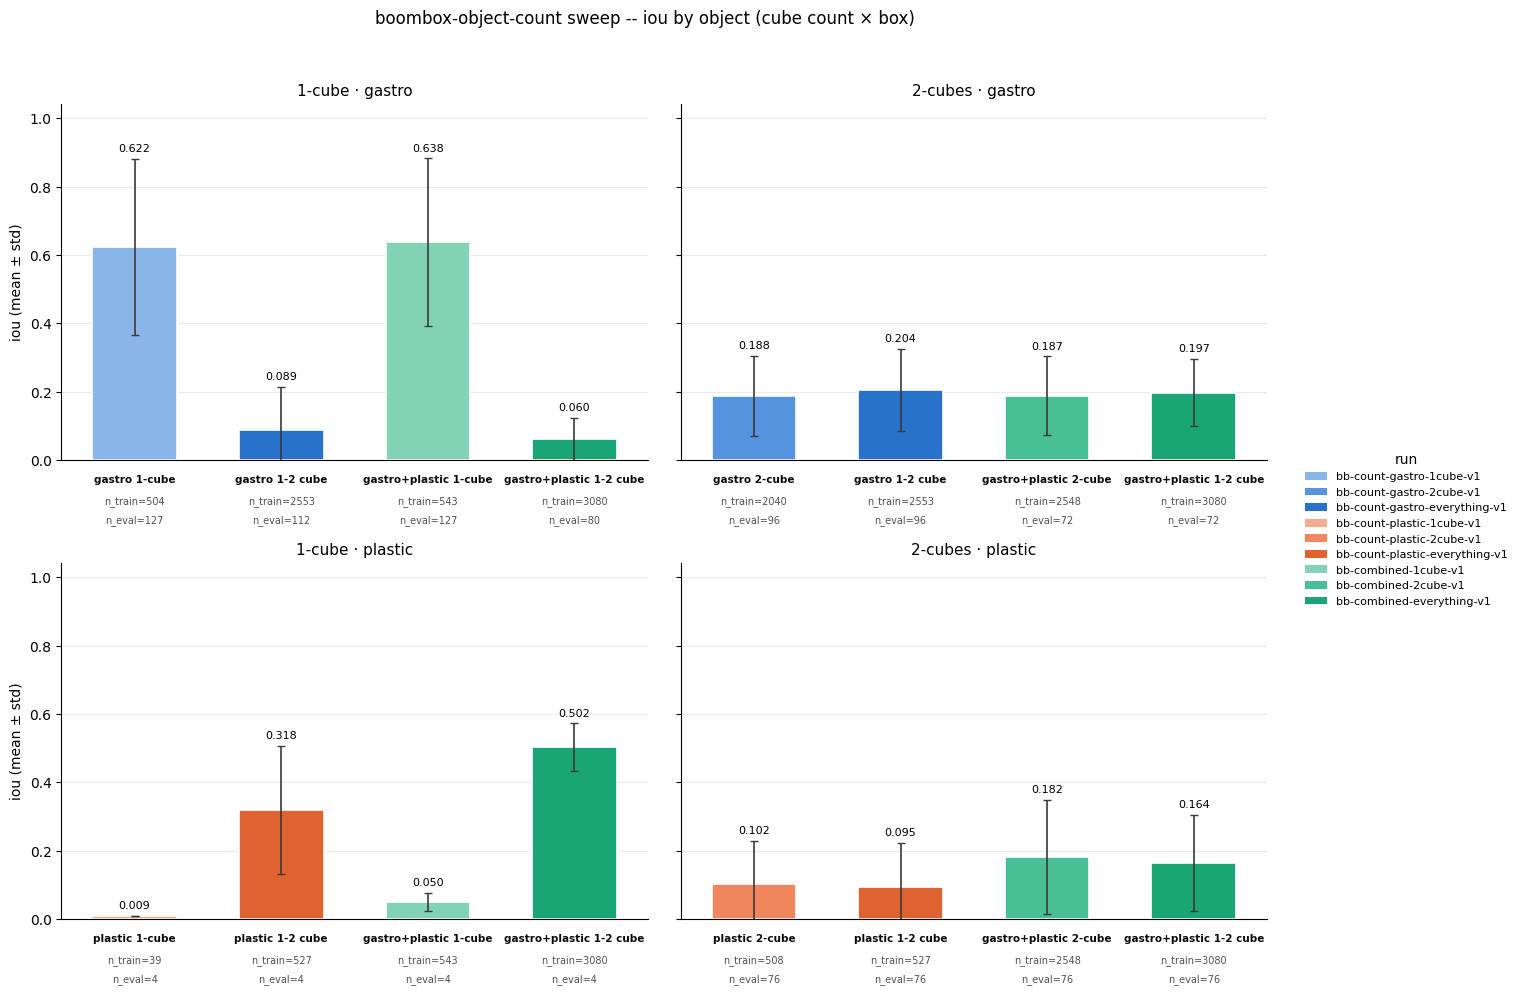

In [5]:
# Categorical hues (validated set, viz skill palette): blue=gastro, orange=plastic, aqua=combined.
FAMILY_HUE = {"gastro": "#2a78d6", "plastic": "#eb6834", "combined": "#1baf7a"}
VARIANT_SHADE = {"1cube": 0.55, "2cube": 0.8, "everything": 1.05}  # blend toward white / toward black


def shade(hex_color: str, factor: float) -> tuple:
    r, g, b = (int(hex_color[i:i+2], 16) / 255 for i in (1, 3, 5))
    if factor <= 1.0:
        r, g, b = (c + (1 - c) * (1 - factor) for c in (r, g, b))  # lighten
    else:
        d = factor - 1.0
        r, g, b = (c * (1 - d) for c in (r, g, b))  # darken
    return (r, g, b)


def run_color(family: str, variant: str) -> tuple:
    return shade(FAMILY_HUE[family], VARIANT_SHADE[variant])


run_order = [name for name, _ in RUN_SPECS]
y_max = (df["mean"] + df["std"]).max() * 1.18  # shared scale across the 4 panels

# 2x2 grid: rows = box, columns = cube count -- reading it row-major gives
# "1-cube gastro, 2-cube gastro, 1-cube plastic, 2-cube plastic".
GRID = [["1-cube · gastro", "2-cubes · gastro"],
        ["1-cube · plastic", "2-cubes · plastic"]]

fig, axes = plt.subplots(2, 2, figsize=(13, 10.5), sharey=True)

bar_w = 0.75
bar_step = bar_w + 0.55  # room for the below-axis labels to not collide

for row in range(2):
    for col in range(2):
        ax = axes[row][col]
        obj = GRID[row][col]
        sub = df[df["object"] == obj]
        bars = [r for _, r in sub.iterrows()]
        bars.sort(key=lambda r: run_order.index(r["run"]))

        below_axis = ax.get_xaxis_transform()
        x = 0.0
        for r in bars:
            color = run_color(r["family"], r["variant"])
            ax.bar(x, r["mean"], width=bar_w, color=color,
                   edgecolor="white", linewidth=1.2, yerr=r["std"], capsize=3,
                   error_kw=dict(ecolor="#3a3a3a", linewidth=1.2))

            ax.text(x, r["mean"] + r["std"] + y_max * 0.015, f"{r['mean']:.3f}",
                    ha="center", va="bottom", fontsize=8)

            ax.text(x, -0.04, box_obj_label(r["family"], r["variant"]), transform=below_axis,
                    ha="center", va="top", fontsize=7.5, fontweight="bold",
                    color="#0b0b0b", clip_on=False)
            ax.text(x, -0.10, f"n_train={TRAIN_N[r['run']]}", transform=below_axis,
                    ha="center", va="top", fontsize=7, color="#52514e", clip_on=False)
            ax.text(x, -0.155, f"n_eval={r['n']}", transform=below_axis,
                    ha="center", va="top", fontsize=7, color="#52514e", clip_on=False)

            x += bar_step

        ax.set_xlim(-bar_step / 2, x - bar_step / 2)
        ax.set_xticks([])
        ax.set_ylim(0, y_max)
        ax.set_title(obj, fontsize=11)
        ax.spines[["top", "right"]].set_visible(False)
        ax.yaxis.grid(True, alpha=0.25)
        ax.set_axisbelow(True)
        if col == 0:
            ax.set_ylabel(f"{METRIC} (mean ± std)")

fig.suptitle(f"boombox-object-count sweep -- {METRIC} by object (cube count × box)", y=0.995)

# Legend: run identity (color) -- the only thing color encodes. Shared across all 4 panels.
run_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=run_color(fam, variant_of(name)), label=name)
               for name, fam in RUN_SPECS]
fig.legend(handles=run_handles, title="run", loc="center left",
           bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=8)

fig.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

## Table

In [6]:
display_df = df[["object", "family", "run", "bucket", "n", "mean", "std"]].copy()
display_df["mean ± std"] = display_df.apply(lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
display_df.style.format({"mean": "{:.4f}", "std": "{:.4f}"}).hide(axis="index")

object,family,run,bucket,n,mean,std,mean ± std
1-cube · gastro,combined,bb-combined-1cube-v1,eval,127,0.6376,0.2449,0.6376 ± 0.2449
1-cube · gastro,combined,bb-combined-everything-v1,eval,80,0.0602,0.0639,0.0602 ± 0.0639
1-cube · gastro,gastro,bb-count-gastro-1cube-v1,eval,127,0.6225,0.2581,0.6225 ± 0.2581
1-cube · gastro,gastro,bb-count-gastro-everything-v1,eval,112,0.0887,0.1255,0.0887 ± 0.1255
1-cube · plastic,combined,bb-combined-1cube-v1,box2-eval,4,0.0498,0.0255,0.0498 ± 0.0255
1-cube · plastic,combined,bb-combined-everything-v1,box2-eval,4,0.5021,0.0700,0.5021 ± 0.0700
1-cube · plastic,plastic,bb-count-plastic-1cube-v1,eval,4,0.0093,0.0000,0.0093 ± 0.0000
1-cube · plastic,plastic,bb-count-plastic-everything-v1,eval,4,0.3181,0.1870,0.3181 ± 0.1870
2-cubes · gastro,combined,bb-combined-2cube-v1,eval,72,0.1875,0.1153,0.1875 ± 0.1153
2-cubes · gastro,combined,bb-combined-everything-v1,eval,72,0.1973,0.0991,0.1973 ± 0.0991
